# Introduction

The purpose of this notebook is to build a chain that:
1. Uses Messages
2. Uses Chat models in graph nodes
3. Uses Tools binded to chat models
4. Execute tool calls in graph nodes

# Import

In [21]:
import tomllib
from typing import Annotated, TypedDict
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, AnyMessage #SystemMessage, BaseMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from IPython.display import display, Image

# Part 1: Messages

In this section, we learn what the various Message classes are (currently will limit to HumanMessage and AIMessage)

In [2]:
# Loading secrets to get API key

with open("../secrets.toml", "rb") as f:
    secrets = tomllib.load(f)

In [3]:
# Creating a message object

m = HumanMessage(content="What is the capital of France?")

m.pretty_print()

================================ Human Message =================================

What is the capital of France?


In [4]:
# Creating a conversation for a Chat Model

messages = [
    HumanMessage(content="Do you know what MCP and A2A protocols are used for?", name="User1"),
    AIMessage(content="Yes, they are used for different purposes when working with LLMs.", name="Model"),
    HumanMessage(content="Are they used for the same purpose?", name="User1"),
    AIMessage(content="No, they have distinct use cases.", name="Model"),
    HumanMessage(content="Can you explain the difference with short and sweet examples?", name="User1"),
]

for m in messages:
    m.pretty_print()

================================ Human Message =================================
Name: User1

Do you know what MCP and A2A protocols are used for?
================================== Ai Message ==================================
Name: Model

Yes, they are used for different purposes when working with LLMs.
================================ Human Message =================================
Name: User1

Are they used for the same purpose?
================================== Ai Message ==================================
Name: Model

No, they have distinct use cases.
================================ Human Message =================================
Name: User1

Can you explain the difference with short and sweet examples?


# Part 2: Chat Models

Note: There is a nuanced difference between LLM models and Chat models. LLM models accept a user query but Chat models can accept a whole conversation exchange.

In [5]:
# Instantiating and LLM object

llm = ChatOpenAI(model="gpt-4o-mini", api_key=secrets["api_keys"]["openai"])
llm.invoke("Test")

AIMessage(content='Test received! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 8, 'total_tokens': 18, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_1c8bdaba3d', 'id': 'chatcmpl-DGRsyiGgpDUv9uqgkpBYrX7iNooNQ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cc3e0-bd61-7611-89b5-db560934c34e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 10, 'total_tokens': 18, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [6]:
res = llm.invoke(messages)
res

AIMessage(content='Certainly! \n\n**MCP (Model Communication Protocol)**: This protocol is used for communication between different components of a machine learning system, such as between a model and a server. For example, it allows a deployed model to receive requests for predictions and send back responses.\n\n**A2A (Application-to-Application) Protocol**: This is used for communication between different applications, often over a network. For instance, it enables two distinct applications to exchange data or commands, like an inventory system updating a sales application about stock levels.\n\nIn summary, MCP focuses on model-specific communication, while A2A is about interaction between different applications.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 128, 'prompt_tokens': 92, 'total_tokens': 220, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens'

In [7]:
res.pretty_print()

================================== Ai Message ==================================

Certainly! 

**MCP (Model Communication Protocol)**: This protocol is used for communication between different components of a machine learning system, such as between a model and a server. For example, it allows a deployed model to receive requests for predictions and send back responses.

**A2A (Application-to-Application) Protocol**: This is used for communication between different applications, often over a network. For instance, it enables two distinct applications to exchange data or commands, like an inventory system updating a sales application about stock levels.

In summary, MCP focuses on model-specific communication, while A2A is about interaction between different applications.


In [8]:
res.response_metadata

{'token_usage': {'completion_tokens': 128,
  'prompt_tokens': 92,
  'total_tokens': 220,
  'completion_tokens_details': {'accepted_prediction_tokens': 0,
   'audio_tokens': 0,
   'reasoning_tokens': 0,
   'rejected_prediction_tokens': 0},
  'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}},
 'model_provider': 'openai',
 'model_name': 'gpt-4o-mini-2024-07-18',
 'system_fingerprint': 'fp_1c8bdaba3d',
 'id': 'chatcmpl-DGRt0KSlw9wbl4sLS5cP8YCfCfFpA',
 'service_tier': 'default',
 'finish_reason': 'stop',
 'logprobs': None}

# Part 3: Tools

Tools are essentially functions that can be exposed to an LLM for it to utlize. Based on the function description and the parameters needed by the function, the LLM can decide if it needs to utilize the tool to answer the users query.

In [9]:
# Creating a tool

def add_numbers(a: int, b: int) -> int:
    """Adds two numbers together."""
    return a + b

In [10]:
llm = llm.bind_tools([add_numbers])

In [11]:
add_res = llm.invoke([HumanMessage("What is 2 + 3?")])
add_res

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 54, 'total_tokens': 72, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a1ddba3226', 'id': 'chatcmpl-DGRt5YCRrvleW5WDCuFVN4ZrjUyb4', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cc3e0-d4cc-7b12-a780-e901b46265e4-0', tool_calls=[{'name': 'add_numbers', 'args': {'a': 2, 'b': 3}, 'id': 'call_F5mw2WtUfFk3Zr4AEwReN5y9', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 54, 'output_tokens': 18, 'total_tokens': 72, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [12]:
add_res.tool_calls

[{'name': 'add_numbers',
  'args': {'a': 2, 'b': 3},
  'id': 'call_F5mw2WtUfFk3Zr4AEwReN5y9',
  'type': 'tool_call'}]

# Part 4: Tools in Graph Nodes

## 4.1: Messages in Graph State

In [ ]:
# Creating a state for storing the messages (using a reducer funtion)

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

# The above State is equivalent to the MessagesState in LangGraph: langgraph.graph import MessagesState
# You can import MessagesState and use it directly or, you can overwrite it as follows (it will still contain the messages field with the reducer):

# langgraph.graph import MessagesState

# class MessagesState(MessagesState):
#     extra_info: str

Note:
1. In the above MessageState, we are adding a reducer function for the messages key. When state is being passed from node to node, LangGraph internally performs a check. If the type is **Annotated**, LangGraph performs an internal operation to execute the function in the metadata of Annotated. If the key to be updated is not of the Annotated type, the value would simply get overwritten.
2. Here, **add_messages** is a **reducer function**. A Reducer is a function that manipulates the state.
3. LangGraph has pre-built reducers that can be leveraged (add_messages is an example)
4. LangGraph also has its own **MessageState** that can be imported and used directly - it has a _messages_ key defined with an add_messages reducer

## 4.2: Graph with Tools

In [24]:
# Creating a node that takes in the messages state and outputs a new messages state with the LLM response

def llm_with_tools_node(state: MessagesState) -> MessagesState:
    res = llm.invoke(state["messages"])
    return {"messages": [res]}

In [27]:
# Building a graph with the above node and the messages state

builder = StateGraph(MessagesState)

builder.add_node("LLM Node",llm_with_tools_node)

builder.add_edge(START, "LLM Node")
builder.add_edge("LLM Node", END)

graph = builder.compile()

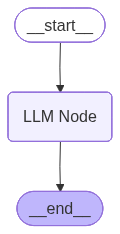

In [30]:
# Displaying the graph

Image(graph.get_graph().draw_mermaid_png())

In [ ]:
# Executing the graph with a query that does not need tools

res = graph.invoke({"messages": [HumanMessage("Hello, how are you?")]})
res # This is the final state after executing the graph

{'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='9d31222f-8a32-4c4e-926f-decc0690ca43'),
  AIMessage(content="Hello! I'm just a program, so I don't have feelings, but I'm here and ready to assist you. How can I help you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 52, 'total_tokens': 82, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a1ddba3226', 'id': 'chatcmpl-DGSmbXefbOHy0iZ5ZFYRwxc468fU4', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cc415-5d73-7880-a292-5c4af1a4d65c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 52, 'output_tokens': 

In [32]:
for m in res["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello, how are you?
================================== Ai Message ==================================

Hello! I'm just a program, so I don't have feelings, but I'm here and ready to assist you. How can I help you today?


In [34]:
# Executing the graph with a query that needs tools

res = graph.invoke({"messages": [HumanMessage("What is 5+4?")]})
for m in res["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 5+4?
================================== Ai Message ==================================
Tool Calls:
  add_numbers (call_Xeyiow16c12IT9icaAk8WyKh)
 Call ID: call_Xeyiow16c12IT9icaAk8WyKh
  Args:
    a: 5
    b: 4


In [ ]:
# Next Step:
# 1. Execute the tool call and respond it to the LLM so it can use the tool response to answer the query
# 2. Add a node for executing the tool call in the graph